# IMPORTS

In [26]:
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

from sklearn.svm import LinearSVC
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

sns.set()

text_feat= 'Text'
engineered_feat = [
    'subject_len', 'body_len', 'text_len',
    'subject_word_count', 'body_word_count', 'text_word_count',
    'exclamation_count', 'question_count', 'url_count', 'digit_count',
    'uppercase_ratio', 'contains_reply', 'contains_forward', 'has_html', 'mean_word_len'
]

# set model and vectorizer configurations
tfidf_config = {
    'ngram_range': (1, 2),
    'max_features': 2000,
    'min_df': 2,
    'max_df': 0.85,
    'norm': 'l2',
    'lowercase': True,
}

svm_config = {
    'C': 0.9,
    'penalty': 'l1',
    'dual': False,
    'max_iter': 3000,
    'random_state': 7,
}

lgbm_config = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'learning_rate': 0.1,
    'num_leaves': 31,
    'max_depth': 6,
    'random_state': 7,
    'n_estimators': 500,
    'n_jobs': -1,
    'verbose': -1
}

catboost_config = {
    'iterations': 500,
    'learning_rate': 0.1,
    'depth': 6,
    'loss_function': 'Logloss',
    'eval_metric': 'F1',
    'random_seed': 7,
    'verbose': 0,
    'thread_count': -1,
}


# columns to drop
drop_columns = [
    'Mime-Version', 'Content-Transfer-Encoding', 'Mail-ID', 'Folder-User',
    'Folder-Name', 'From', 'To', 'Suspicious-Folders', 'Date', 'Message-ID',
    'Content-Type', 'X-From', 'X-To', 'X-cc', 'X-bcc', 'X-Origin', 'X-Folder',
    'Cc', 'Attendees', 'Bcc', 'Time', 'X-FileName', 'Re', 'Source',
    'POI-Present', 'Low-Comm', 'Contains-Reply-Forwards', 'Sender-Type',
    'Unique-Mails-From-Sender',
]

# patterns to look for
URL_PATTERN = r'https?://\S+|www\.\S+'
REPLY_PATTERN = r'(re:|reply|respond)'
FORWARD_PATTERN = r'(fwd:|fw:|forward)'
HTML_PATTERN = r'<[^>]+>'

# return .csv dataset
def get_data(path):
    return pd.read_csv(path)


def _safe_mean_word_length(text: str) -> float:
    words = text.split()
    return float(np.mean([len(word) for word in words])) if words else 0.0


def preprocess(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()
    data.drop(columns=drop_columns, inplace=True, errors='ignore')

    data['Subject'] = data['Subject'].fillna('no_subject').astype(str)
    data['Body'] = data['Body'].fillna('').astype(str)
    data['Text'] = data['Subject'] + ' ' + data['Body']

    text_series = data['Text'].astype(str)
    data['subject_len'] = data['Subject'].str.len()
    data['body_len'] = data['Body'].str.len()
    data['text_len'] = text_series.str.len()

    data['subject_word_count'] = data['Subject'].str.split().str.len()
    data['body_word_count'] = data['Body'].str.split().str.len()
    data['text_word_count'] = text_series.str.split().str.len()

    data['exclamation_count'] = text_series.str.count('!')
    data['question_count'] = text_series.str.count(r'\?')
    data['url_count'] = text_series.str.count(URL_PATTERN)
    data['digit_count'] = text_series.str.count(r'\d')

    uppercase_chars = text_series.str.findall(r'[A-Z]').str.len().fillna(0)
    text_len = text_series.str.len().replace(0, 1)
    data['uppercase_ratio'] = uppercase_chars / text_len

    data['contains_reply'] = data['Subject'].str.contains(REPLY_PATTERN, case=False, na=False).astype(int)
    data['contains_forward'] = data['Subject'].str.contains(FORWARD_PATTERN, case=False, na=False).astype(int)
    data['has_html'] = text_series.str.contains(HTML_PATTERN, na=False).astype(int)

    data['mean_word_len'] = data['Body'].apply(_safe_mean_word_length)
    data.drop(columns=['Subject', 'Body'], inplace=True)
    return data


def _build_pipeline():
    return Pipeline(
        steps=[
            ('preprocessor', ColumnTransformer(
                transformers=[
                    ('tfidf', TfidfVectorizer(**tfidf_config), text_feat),
                    ('scaler', StandardScaler(), engineered_feat),
                ]
            )),
            ('estimator', None),
        ]
    )

# baseline
def train_svm(x_train: pd.DataFrame, y_train: pd.Series):
    pipeline= _build_pipeline()
    pipeline.steps[-1]= ('estimator', LinearSVC(**svm_config))
    pipeline= Pipeline(pipeline.steps)
    
    return pipeline.fit(x_train, y_train)

# better gbtree models
def train_lgbm(x_train: pd.DataFrame, y_train: pd.Series):
    pipeline = _build_pipeline()
    pipeline.steps[-1] = ('estimator', LGBMClassifier(**lgbm_config))
    pipeline = Pipeline(pipeline.steps)
    
    lgbm_model = pipeline.fit(x_train, y_train)
    return lgbm_model
    
def train_catboost(x_train: pd.DataFrame, y_train: pd.Series):
    model = CatBoostClassifier(**catboost_config)
    text_feats = [text_feat] if text_feat in x_train.columns else []
    model.fit(x_train, y_train, text_features= text_feats)
    return model

def train_stacking_classifier(x_train, y_train):
    preprocessor= ColumnTransformer([
        ('tfidf', TfidfVectorizer(**tfidf_config), text_feat),
        ('scaler', StandardScaler(), engineered_feat),])

    # define base learner pipe
    lgbm_pipe= Pipeline([
        ('lgbm_preprocessor', preprocessor),
        ('lgbm_estimator', LGBMClassifier(**lgbm_config)) 
    ])
    
    catboost_pipe= Pipeline([
        ('catboost_preprocessor', preprocessor),
        ('catboost_estimator', CatBoostClassifier(**catboost_config))
    ])

    base_lrnrs =[('lgbm', lgbm_pipe), 
                 ('catboost', catboost_pipe)]


    meta_estim = LogisticRegression(
        C=1.0, 
        penalty='l2', 
        random_state=7, 
    )
    stack_model = StackingClassifier(
        estimators=base_lrnrs,
        final_estimator=meta_estim,
        cv=5,
        stack_method='predict_proba',
        n_jobs=-1
    )

    return stack_model.fit(x_train, y_train)

# LOAD & PREPROCESS DATA

In [27]:
# Download the dataset and load the CSV file
dataset_folder = kagglehub.dataset_download("advaithsrao/enron-fraud-email-dataset")
print("Dataset folder:", dataset_folder)

csv_files = [file for file in os.listdir(dataset_folder) if file.endswith('.csv')]
full_path = os.path.join(dataset_folder, csv_files[0])
print("Loading data from:", full_path)
raw_data = get_data(full_path)
raw_data.head()

Dataset folder: /kaggle/input/datasets/advaithsrao/enron-fraud-email-dataset
Loading data from: /kaggle/input/datasets/advaithsrao/enron-fraud-email-dataset/enron_data_fraud_labeled.csv


/tmp/ipykernel_57/3252085927.py:94: DtypeWarning: Columns (7,13) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path)


,Folder-User,Folder-Name,Message-ID,Date,From,To,Subject,Mime-Version,Content-Type,Content-Transfer-Encoding,...,Re,Source,Mail-ID,POI-Present,Suspicious-Folders,Sender-Type,Unique-Mails-From-Sender,Low-Comm,Contains-Reply-Forwards,Label
0,maildir,arnold-j,<17334447.1075857585446.JavaMail.evans@thyme>,"Thu, 16 Nov 2000 09:30:00 -0800 (PST)",msagel@home.com,jarnold@enron.com,Status,1.0,text/plain; charset=ANSI_X3.4-1968,7bit,...,,Enron Data,b399fa1ba5ec06ccf8ead1049a53be981d0ebb39ee2c94...,False,False,External,18.0,False,False,0
1,maildir,arnold-j,<19171686.1075857585034.JavaMail.evans@thyme>,"Fri, 8 Dec 2000 05:05:00 -0800 (PST)",slafontaine@globalp.com,john.arnold@enron.com,re:summer inverses,1.0,text/plain; charset=us-ascii,7bit,...,,Enron Data,84b07d7a0a17b545896f670f92d200e86843c2796147d9...,False,False,External,4.0,True,False,0
2,maildir,arnold-j,<29887033.1075857630725.JavaMail.evans@thyme>,"Tue, 15 May 2001 09:43:00 -0700 (PDT)",iceoperations@intcx.com,"icehelpdesk@intcx.com, internalmarketing@intcx...",The WTI Bullet swap contracts,1.0,text/plain; charset=us-ascii,7bit,...,,Enron Data,f7482dd06262f46d341e733aa0c2fb55cb1e257ea153d0...,False,False,External,3.0,True,False,0
3,maildir,arnold-j,<2526360.1075857584903.JavaMail.evans@thyme>,"Mon, 11 Dec 2000 23:52:00 -0800 (PST)",klarnold@flash.net,john.arnold@enron.com,Fwd: NYTimes.com Article: Suspended Rabbi Quit...,1.0,text/plain; charset=us-ascii,7bit,...,,Enron Data,25441e5a837fefda50527731fdbcdf0848663be82cd1ce...,False,False,External,9.0,False,True,0
4,maildir,arnold-j,<30102065.1075857630952.JavaMail.evans@thyme>,"Mon, 14 May 2001 23:59:00 -0700 (PDT)",soblander@carrfut.com,soblander@carrfut.com,daily charts and matrices as hot links 5/15,1.0,text/plain; charset=us-ascii,7bit,...,,Enron Data,c2995c6a70b953ee66c21d8a509ebfbfaca28277917beb...,False,False,External,352.0,False,False,0


In [28]:
print("Rows:", raw_data.shape[0])
print("Columns:", raw_data.shape[1])
print("Label values:\n", raw_data['Label'].value_counts())
print("\nMissing values by column:\n", raw_data.isnull().sum()[raw_data.isnull().sum() > 0])

Rows: 447417
Columns: 32
Label values:
 Label
0    445090
1      2327
Name: count, dtype: int64

Missing values by column:
 Subject        18020
X-To            8179
X-cc          337780
X-bcc         447240
X-FileName      2690
dtype: int64


# FEATURE ENGINEERING & PREPARATION

In [29]:
prepared_data = preprocess(raw_data)
prepared_data.head()

/tmp/ipykernel_57/3252085927.py:128: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  data['contains_reply'] = data['Subject'].str.contains(REPLY_PATTERN, case=False, na=False).astype(int)
/tmp/ipykernel_57/3252085927.py:129: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  data['contains_forward'] = data['Subject'].str.contains(FORWARD_PATTERN, case=False, na=False).astype(int)


,Label,Text,subject_len,body_len,text_len,subject_word_count,body_word_count,text_word_count,exclamation_count,question_count,url_count,digit_count,uppercase_ratio,contains_reply,contains_forward,has_html,mean_word_len
0,0,Status Status John: I'm not really sure what h...,6,592,599,1,101,102,0,13,0,18,0.030050,0,0,0,4.871287
1,0,re:summer inverses re:summer inverses i suck-h...,18,295,314,2,53,55,0,4,0,1,0.000000,1,0,0,4.566038
2,0,The WTI Bullet swap contracts The WTI Bullet s...,29,1083,1113,5,173,178,0,0,0,62,0.077269,0,0,0,5.265896
3,0,Fwd: NYTimes.com Article: Suspended Rabbi Quit...,67,195,263,8,16,24,0,0,0,2,0.095057,0,1,0,11.187500
4,0,daily charts and matrices as hot links 5/15 da...,43,1119,1163,8,190,198,0,0,0,42,0.050731,0,0,1,4.894737


/tmp/ipykernel_57/1363436262.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Label', data=prepared_data, palette='pastel', edgecolor='black')


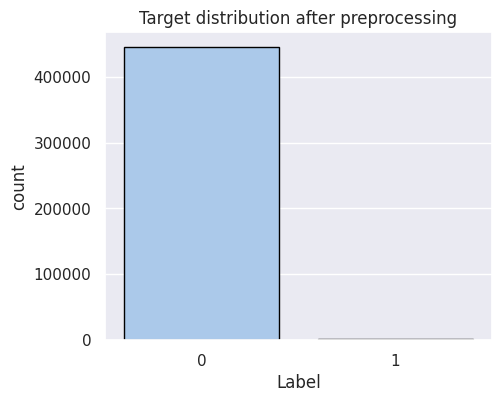

,count,mean,std,min,25%,50%,75%,max
subject_len,447417.0,28.180132,19.243248,1.0,14.000000,24.000000,38.000000,2.580000e+02
body_len,447417.0,893.088396,5357.978850,1.0,124.000000,232.000000,565.000000,1.401129e+06
text_len,447417.0,922.268528,5358.935817,3.0,151.000000,262.000000,597.000000,1.401137e+06
subject_word_count,447417.0,4.445023,2.973332,1.0,2.000000,4.000000,6.000000,4.900000e+01
body_word_count,447417.0,141.744207,733.609083,0.0,19.000000,38.000000,94.000000,6.277500e+04
text_word_count,447417.0,146.189231,733.747073,1.0,23.000000,43.000000,99.000000,6.277900e+04
uppercase_ratio,447417.0,0.101910,0.076085,0.0,0.054608,0.084951,0.127517,9.236641e-01
mean_word_len,447417.0,5.325112,1.307883,0.0,4.594937,5.104167,5.744186,9.875000e+01


In [30]:
plt.figure(figsize=(5, 4))
sns.countplot(x='Label', data=prepared_data, palette='pastel', edgecolor='black')
plt.title('Target distribution after preprocessing')
plt.show()

prepared_data[['subject_len', 'body_len', 'text_len', 'subject_word_count', 'body_word_count', 'text_word_count', 'uppercase_ratio', 'mean_word_len']].describe().T

In [31]:
X = prepared_data.drop(columns=['Label'])
y = prepared_data['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=7,
    stratify=y,
)

# create validation set
X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=7,
    stratify=y
)


print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Train label distribution:\n', y_train.value_counts())
print('Test label distribution:\n', y_test.value_counts())

Train shape: (357933, 16)
Test shape: (89484, 16)
Train label distribution:
 Label
0    356071
1      1862
Name: count, dtype: int64
Test label distribution:
 Label
0    89019
1      465
Name: count, dtype: int64


# MODEL TRAINING

In [32]:
svm_model = train_svm(X_train, y_train)
print("SVM training complete")

lgbm_model= train_lgbm(X_train, y_train)
print("LGBM training complete")

catboost_model = train_catboost(X_train, y_train)
print("CatBoost training complete")

stacking_class_model= train_stacking_classifier(X_train, y_train)
print("Stacking Classifier training complete")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training Complete


# EVALUATION

In [57]:
def evaluate(name, model, X_eval, y_eval, scores):
    preds = model.predict(X_eval)
   
    print(f"--->{name}<---")
    print(f"Precision: {precision_score(y_eval, preds):.2f}")
    scores.append(precision_score(y_eval, preds))
    print(f"Recall:    {recall_score(y_eval, preds):.2f}")
    scores.append(recall_score(y_eval, preds))
    print(f"F1 score:  {f1_score(y_eval, preds):.2f}")
    scores.append(f1_score(y_eval, preds))
    print("Confusion matrix:\n", confusion_matrix(y_eval, preds))
    print("Classification report:\n", classification_report(y_eval, preds))

svm_scores= []
lgbm_scores= []
catboost_scores= []
stacking_classifier_scores= []

evaluate('SVM', svm_model, X_test, y_test, svm_scores)
evaluate('LGBM,', lgbm_model, X_test, y_test, lgbm_scores)
evaluate('CatBoost', catboost_model, X_test, y_test, catboost_scores)
evaluate('StackingClassifier', stacking_class_model, X_test, y_test, stacking_classifier_scores)

ERROR! Session/line number was not unique in database. History logging moved to new session 29
--->SVM<---
Precision: 0.76
Recall:    0.45
F1 score:  0.56
Confusion matrix:
 [[88955    64]
 [  257   208]]
Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     89019
           1       0.76      0.45      0.56       465

    accuracy                           1.00     89484
   macro avg       0.88      0.72      0.78     89484
weighted avg       1.00      1.00      1.00     89484



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


--->LGBM,<---
Precision: 0.78
Recall:    0.66
F1 score:  0.71
Confusion matrix:
 [[88931    88]
 [  158   307]]
Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     89019
           1       0.78      0.66      0.71       465

    accuracy                           1.00     89484
   macro avg       0.89      0.83      0.86     89484
weighted avg       1.00      1.00      1.00     89484

--->CatBoost<---
Precision: 0.89
Recall:    0.53
F1 score:  0.66
Confusion matrix:
 [[88988    31]
 [  220   245]]
Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     89019
           1       0.89      0.53      0.66       465

    accuracy                           1.00     89484
   macro avg       0.94      0.76      0.83     89484
weighted avg       1.00      1.00      1.00     89484



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


--->StackingClassifier<---
Precision: 0.85
Recall:    0.64
F1 score:  0.73
Confusion matrix:
 [[88965    54]
 [  166   299]]
Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     89019
           1       0.85      0.64      0.73       465

    accuracy                           1.00     89484
   macro avg       0.92      0.82      0.86     89484
weighted avg       1.00      1.00      1.00     89484



In [ ]:
import numpy as np
from sklearn.metrics import classification_report, f1_score
print(f"Stacking Classifier Model")

y_probs = stacking_class_model.predict_proba(X_val)[:, 1] # type: ignore

best_threshold = 0.5
best_f1 = 0.0

print(f"{'Threshold':<10} | {'F1-Score':<10}")
print("-" * 30)

for threshold in np.arange(0.1, 0.6, 0.05):
    y_pred_adj = (y_probs >= threshold).astype(int)
    current_f1 = f1_score(y_val, y_pred_adj)
    
    print(f"{threshold:.2f} | {current_f1:.4f}")
    
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = threshold

print(f"\nOptimal Threshold found: {best_threshold:.2f} with F1-Score: {best_f1:.4f}")

final_preds = (y_probs >= best_threshold).astype(int)
print("\nFinal Adjusted Classification Report:")
print(classification_report(y_val, final_preds))

Stacking Classifier Model


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Threshold  | F1-Score  
------------------------------
0.10 | 0.7235
0.15 | 0.7194
0.20 | 0.7240
0.25 | 0.7194
0.30 | 0.7136
0.35 | 0.7158
0.40 | 0.7155
0.45 | 0.7288
0.50 | 0.7311
0.55 | 0.7297

Optimal Threshold found: 0.50 with F1-Score: 0.7311

Final Adjusted Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     89019
           1       0.85      0.64      0.73       465

    accuracy                           1.00     89484
   macro avg       0.92      0.82      0.86     89484
weighted avg       1.00      1.00      1.00     89484



In [39]:
import numpy as np
from sklearn.metrics import classification_report, f1_score
print(f"CatBoost Model")

y_probs = catboost_model.predict_proba(X_val)[:, 1]

best_threshold = 0.5
best_f1 = 0.0

print(f"{'Threshold':<10} | {'F1-Score':<10}")
print("-" * 30)

for threshold in np.arange(0.1, 0.6, 0.05):
    y_pred_adj = (y_probs >= threshold).astype(int)
    current_f1 = f1_score(y_val, y_pred_adj)
    
    print(f"{threshold:.2f} | {current_f1:.4f}")
    
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = threshold

print(f"\nOptimal Threshold found: {best_threshold:.2f} with F1-Score: {best_f1:.4f}")

final_preds = (y_probs >= best_threshold).astype(int)
print("\nFinal Adjusted Classification Report:")
print(classification_report(y_val, final_preds))

CatBoost Model
Threshold  | F1-Score  
------------------------------
0.10 | 0.5835
0.15 | 0.6387
0.20 | 0.6899
0.25 | 0.7053
0.30 | 0.7055
0.35 | 0.7102
0.40 | 0.6963
0.45 | 0.6763
0.50 | 0.6613
0.55 | 0.6322

Optimal Threshold found: 0.35 with F1-Score: 0.7102

Final Adjusted Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     89019
           1       0.83      0.62      0.71       465

    accuracy                           1.00     89484
   macro avg       0.92      0.81      0.85     89484
weighted avg       1.00      1.00      1.00     89484



In [40]:
import numpy as np
from sklearn.metrics import classification_report, f1_score
print(f"LGBM Model")

y_probs = lgbm_model.predict_proba(X_val)[:, 1]

best_threshold = 0.5
best_f1 = 0.0

print(f"{'Threshold':<10} | {'F1-Score':<10}")
print("-" * 30)

for threshold in np.arange(0.1, 0.6, 0.05):
    y_pred_adj = (y_probs >= threshold).astype(int)
    current_f1 = f1_score(y_val, y_pred_adj)
    
    print(f"{threshold:.2f} | {current_f1:.4f}")
    
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = threshold

print(f"\nOptimal Threshold found: {best_threshold:.2f} with F1-Score: {best_f1:.4f}")

final_preds = (y_probs >= best_threshold).astype(int)
print("\nFinal Adjusted Classification Report:")
print(classification_report(y_val, final_preds))

LGBM Model


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Threshold  | F1-Score  
------------------------------
0.10 | 0.6932
0.15 | 0.7110
0.20 | 0.7144
0.25 | 0.7205
0.30 | 0.7171
0.35 | 0.7170
0.40 | 0.7114
0.45 | 0.7158
0.50 | 0.7140
0.55 | 0.7091

Optimal Threshold found: 0.25 with F1-Score: 0.7205

Final Adjusted Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     89019
           1       0.73      0.71      0.72       465

    accuracy                           1.00     89484
   macro avg       0.87      0.85      0.86     89484
weighted avg       1.00      1.00      1.00     89484



In [41]:
print(f"SVM Model")
y_scores = svm_model.decision_function(X_val)

best_threshold = 0.5
best_f1 = 0.0

print(f"{'Threshold':<10} | {'F1-Score':<10}")
print("-" * 30)

for threshold in np.arange(-2.0, 2.0, 0.25):
    y_pred_adj = (y_scores >= threshold).astype(int)
    current_f1 = f1_score(y_val, y_pred_adj)
    
    print(f"{threshold:>10.2f} | {current_f1:.4f}")
    
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = threshold

print(f"\nOptimal Score Threshold found: {best_threshold:.2f} with F1-Score: {best_f1:.4f}")

final_preds = (y_scores >= best_threshold).astype(int)
print("\nFinal Adjusted Classification Report:")
print(classification_report(y_val, final_preds))

SVM Model
Threshold  | F1-Score  
------------------------------
     -2.00 | 0.0406
     -1.75 | 0.0633
     -1.50 | 0.1063
     -1.25 | 0.1811
     -1.00 | 0.3111
     -0.75 | 0.5052
     -0.50 | 0.6110
     -0.25 | 0.6289
      0.00 | 0.5645
      0.25 | 0.4610
      0.50 | 0.2591
      0.75 | 0.1434
      1.00 | 0.0380
      1.25 | 0.0043
      1.50 | 0.0000
      1.75 | 0.0000

Optimal Score Threshold found: -0.25 with F1-Score: 0.6289

Final Adjusted Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     89019
           1       0.68      0.58      0.63       465

    accuracy                           1.00     89484
   macro avg       0.84      0.79      0.81     89484
weighted avg       1.00      1.00      1.00     89484



# CONCLUSION


In [68]:
models = [svm_model, lgbm_model, catboost_model, stacking_class_model]

print(f"{'Model Name':<20} | {'Precision':>12} | {'Recall':>12} | {'F1 Score':>12}")
print("-" * 70)

for m in models:
    if m == svm_model:
        name = 'LinearSVC'
        scores = svm_scores
    elif m == lgbm_model:
        name = 'LGBM'
        scores = lgbm_scores
    elif m == catboost_model:
        name = 'CatBoost'
        scores = catboost_scores
    else:
        name = 'Stacked Classifier'
        scores = stacking_classifier_scores
    
    print(f"{name:<20} | {scores[0]:>12.2f} | {scores[1]:>12.2f} | {scores[2]:>12.2f}")

Model Name           |    Precision |       Recall |     F1 Score
----------------------------------------------------------------------
LinearSVC            |         0.76 |         0.45 |         0.56
LGBM                 |         0.78 |         0.66 |         0.71
CatBoost             |         0.89 |         0.53 |         0.66
Stacked Classifier   |         0.85 |         0.64 |         0.73


Clearly the Stacked Classifier brings the best of both the meta learners LGBM and CatBoost.